# Part 0 Images

## Setup

### Imports

In [1]:
import os

In [2]:
from manim import *

### Configuration

Decide whether to display output.

In [3]:
os.environ["MANIM_DISPLAY"] = "True"

Set up magics to handle correct display procedure.

In [4]:
%load_ext toggle_display

Loaded toggle display extension.


## Scenes

### Chapter 3: Relations

The "is born in" relation diagram.

Manim Community v0.18.1

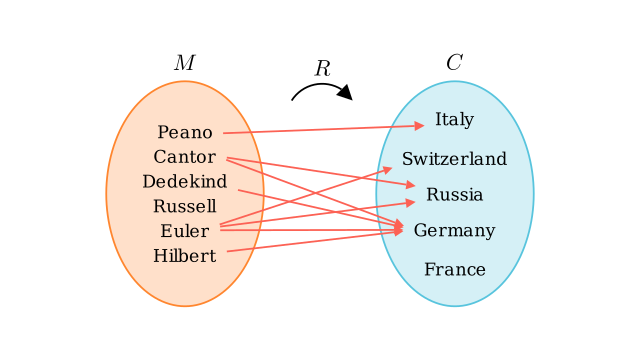

In [5]:
%%handle_display
%%manim --output_file 0-relations-lived-in-relation.png RelationDiagram

M_FONT_SIZE = 28
C_FONT_SIZE = 28

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class RelationDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_m = Ellipse(width=3.5, height=5, color=ORANGE)
        ellipse_m.set_fill(ORANGE, opacity=0.25)
        ellipse_m.shift(LEFT * 3)
        
        ellipse_c = Ellipse(width=3.5, height=5, color=BLUE)
        ellipse_c.set_fill(BLUE, opacity=0.25)
        ellipse_c.shift(RIGHT * 3)
        
        # Create labels for the ellipses
        label_m = MathTex("M", color=BLACK).next_to(ellipse_m, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)
        
        # Create elements for sets M
        elements_m = ["Peano", "Cantor", "Dedekind", "Russell", "Euler", "Hilbert"]
        elements_c = ["Italy", "Switzerland", "Russia", "Germany", "France"]

        elements_m = [Text(m, font_size=M_FONT_SIZE, color=BLACK) for m in elements_m]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_m = VGroup(*elements_m).arrange(DOWN, buff=0.25).move_to(ellipse_m)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.5).move_to(ellipse_c)
        
        # Create arrows
        arrow_links = [
            (0, 0),  # Peano-Italy
            (1, 2),  # Cantor-Russia  
            (1, 3),  # Cantor-Germany
            (2, 3),  # Dedekind-Germany
            (4, 1),  # Euler-Switzerland
            (4, 2),  # Euler-Russia
            (4, 3),  # Euler-Germany
            (5, 3)   # Hilbert-Germany
        ]
        arrows = [
            Arrow(
                elements_m[i],
                elements_c[j],
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add relation label above the arrows
        relation_label = MathTex("R", color=BLACK).next_to(arrows, 4*UP)
        relation_label.add(CurvedArrow(relation_label.get_left() + LEFT * 0.5, relation_label.get_right() + RIGHT * 0.5, stroke_width=ARROW_STROKE_WIDTH, color=BLACK).flip(LEFT).shift(DOWN * 0.35))

        # Add all elements to the scene
        group = Group(ellipse_m, ellipse_c, label_m, label_c, elements_m, elements_c, arrows, relation_label)
        group.center()
        self.add(group)